In [1]:
import pandas as pd

# Load the data
df = pd.read_csv('diabetes.csv')

# Inspect the data
print(df.head())
print(df.info())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Load data
df = pd.read_csv('diabetes.csv')
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Feature Selection ---
# Use Random Forest to get feature importances
rf_selector = RandomForestClassifier(random_state=42)
rf_selector.fit(X_train_scaled, y_train)
importances = rf_selector.feature_importances_
feature_ranking = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Select top 4 features based on importance
top_features = feature_ranking['Feature'].head(4).tolist()
top_indices = [X.columns.get_loc(col) for col in top_features]
X_train_selected = X_train_scaled[:, top_indices]
X_test_selected = X_test_scaled[:, top_indices]

# --- Feature Extraction: PCA ---
pca = PCA(n_components=4, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
explained_variance = pca.explained_variance_ratio_

# --- Feature Extraction: LDA ---
lda = LDA(n_components=1)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

# Define models to compare
def evaluate_model(X_tr, X_te, y_tr, y_te, name):
    # We will test Logistic Regression
    lr = LogisticRegression(random_state=42)
    lr.fit(X_tr, y_tr)
    y_pred = lr.predict(X_te)

    return {
        'Approach': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1-Score': f1_score(y_te, y_pred)
    }

results = []
results.append(evaluate_model(X_train_scaled, X_test_scaled, y_train, y_test, 'All Features (Baseline)'))
results.append(evaluate_model(X_train_selected, X_test_selected, y_train, y_test, 'Selected Features (Top 4)'))
results.append(evaluate_model(X_train_pca, X_test_pca, y_train, y_test, 'PCA (4 Components)'))
results.append(evaluate_model(X_train_lda, X_test_lda, y_train, y_test, 'LDA (1 Component)'))

results_df = pd.DataFrame(results)

print("Feature Rankings:")
print(feature_ranking)
print("\nPCA Explained Variance Ratio:")
print(explained_variance, "Total:", sum(explained_variance))
print("\nModel Evaluation Results (Logistic Regression):")
print(results_df)

# Let's also check Random Forest classifier performance to see if it differs
results_rf = []
def evaluate_rf(X_tr, X_te, y_tr, y_te, name):
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_te)
    return {
        'Approach': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1-Score': f1_score(y_te, y_pred)
    }

results_rf.append(evaluate_rf(X_train_scaled, X_test_scaled, y_train, y_test, 'All Features (Baseline)'))
results_rf.append(evaluate_rf(X_train_selected, X_test_selected, y_train, y_test, 'Selected Features (Top 4)'))
results_rf.append(evaluate_rf(X_train_pca, X_test_pca, y_train, y_test, 'PCA (4 Components)'))
results_rf.append(evaluate_rf(X_train_lda, X_test_lda, y_train, y_test, 'LDA (1 Component)'))

results_rf_df = pd.DataFrame(results_rf)
print("\nModel Evaluation Results (Random Forest):")
print(results_rf_df)

Feature Rankings:
                    Feature  Importance
1                   Glucose    0.276009
5                       BMI    0.159544
7                       Age    0.127248
6  DiabetesPedigreeFunction    0.126731
2             BloodPressure    0.085606
0               Pregnancies    0.084456
4                   Insulin    0.072409
3             SkinThickness    0.067997

PCA Explained Variance Ratio:
[0.26073778 0.21817547 0.13091879 0.10528263] Total: 0.7151146665363749

Model Evaluation Results (Logistic Regression):
                    Approach  Accuracy  Precision    Recall  F1-Score
0    All Features (Baseline)  0.714286   0.608696  0.518519  0.560000
1  Selected Features (Top 4)  0.727273   0.636364  0.518519  0.571429
2         PCA (4 Components)  0.688312   0.571429  0.444444  0.500000
3          LDA (1 Component)  0.714286   0.608696  0.518519  0.560000

Model Evaluation Results (Random Forest):
                    Approach  Accuracy  Precision    Recall  F1-Score
0    Al

In [3]:
# Check how many zeros there are in columns where zero is invalid
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Zero counts before imputation:")
print((df[cols_with_zeros] == 0).sum())

# Let's try replacing zeros with NaN and then imputing with median
df_imputed = df.copy()
for col in cols_with_zeros:
    df_imputed[col] = df_imputed[col].replace(0, np.nan)

# Fill NaN with median of that column
df_imputed.fillna(df_imputed.median(), inplace=True)

X_imp = df_imputed.drop(columns=['Outcome'])
y_imp = df_imputed['Outcome']

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(X_imp, y_imp, test_size=0.2, random_state=42, stratify=y_imp)

scaler_imp = StandardScaler()
X_train_imp_scaled = scaler_imp.fit_transform(X_train_imp)
X_test_imp_scaled = scaler_imp.transform(X_test_imp)

# Feature selection on imputed data
rf_imp = RandomForestClassifier(random_state=42)
rf_imp.fit(X_train_imp_scaled, y_train_imp)
imp_features = pd.DataFrame({'Feature': X_imp.columns, 'Importance': rf_imp.feature_importances_}).sort_values(by='Importance', ascending=False)
print("\nFeature Rankings after imputation:")
print(imp_features)

top_features_imp = imp_features['Feature'].head(4).tolist()
top_indices_imp = [X_imp.columns.get_loc(col) for col in top_features_imp]
X_train_imp_sel = X_train_imp_scaled[:, top_indices_imp]
X_test_imp_sel = X_test_imp_scaled[:, top_indices_imp]

# PCA on imputed data
pca_imp = PCA(n_components=4, random_state=42)
X_train_imp_pca = pca_imp.fit_transform(X_train_imp_scaled)
X_test_imp_pca = pca_imp.transform(X_test_imp_scaled)

# LDA on imputed data
lda_imp = LDA(n_components=1)
X_train_imp_lda = lda_imp.fit_transform(X_train_imp_scaled, y_train_imp)
X_test_imp_lda = lda_imp.transform(X_test_imp_scaled)

results_lr_imp = []
results_lr_imp.append(evaluate_model(X_train_imp_scaled, X_test_imp_scaled, y_train_imp, y_test_imp, 'All Features (Baseline)'))
results_lr_imp.append(evaluate_model(X_train_imp_sel, X_test_imp_sel, y_train_imp, y_test_imp, 'Selected Features (Top 4)'))
results_lr_imp.append(evaluate_model(X_train_imp_pca, X_test_imp_pca, y_train_imp, y_test_imp, 'PCA (4 Components)'))
results_lr_imp.append(evaluate_model(X_train_imp_lda, X_test_imp_lda, y_train_imp, y_test_imp, 'LDA (1 Component)'))

print("\nLogistic Regression results with Imputation:")
print(pd.DataFrame(results_lr_imp))

results_rf_imp = []
results_rf_imp.append(evaluate_rf(X_train_imp_scaled, X_test_imp_scaled, y_train_imp, y_test_imp, 'All Features (Baseline)'))
results_rf_imp.append(evaluate_rf(X_train_imp_sel, X_test_imp_sel, y_train_imp, y_test_imp, 'Selected Features (Top 4)'))
results_rf_imp.append(evaluate_rf(X_train_imp_pca, X_test_imp_pca, y_train_imp, y_test_imp, 'PCA (4 Components)'))
results_rf_imp.append(evaluate_rf(X_train_imp_lda, X_test_imp_lda, y_train_imp, y_test_imp, 'LDA (1 Component)'))

print("\nRandom Forest results with Imputation:")
print(pd.DataFrame(results_rf_imp))

Zero counts before imputation:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Feature Rankings after imputation:
                    Feature  Importance
1                   Glucose    0.274086
5                       BMI    0.161903
6  DiabetesPedigreeFunction    0.125020
7                       Age    0.112985
4                   Insulin    0.091224
2             BloodPressure    0.083518
0               Pregnancies    0.080795
3             SkinThickness    0.070468

Logistic Regression results with Imputation:
                    Approach  Accuracy  Precision    Recall  F1-Score
0    All Features (Baseline)  0.707792   0.600000  0.500000  0.545455
1  Selected Features (Top 4)  0.720779   0.622222  0.518519  0.565657
2         PCA (4 Components)  0.701299   0.583333  0.518519  0.549020
3          LDA (1 Component)  0.701299   0.590909  0.481481  0.530612

Random Forest results with Imputation:
                   

C:\Users\VICKKY\AppData\Local\Temp\ipykernel_16760\1025009927.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_features, x='Importance', y='Feature', palette='viridis')


Plots saved successfully.


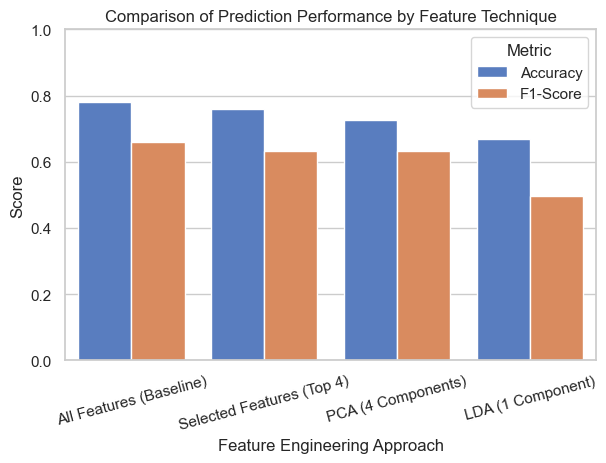

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# Plot 1: Feature Importance
plt.clf()
sns.barplot(data=imp_features, x='Importance', y='Feature', palette='viridis')
plt.title('Significant Medical Parameters (Feature Importance via Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Medical Parameter')
plt.tight_layout()
plt.savefig('feature_importance.png')

# Plot 2: Model Performance Comparison (Random Forest)
df_rf_perf = pd.DataFrame(results_rf_imp)
# Melt the dataframe for plotting multiple metrics if needed, or just plot Accuracy and F1-Score
df_melted = df_rf_perf.melt(id_vars='Approach', value_vars=['Accuracy', 'F1-Score'], var_name='Metric', value_name='Score')

plt.clf()
sns.barplot(data=df_melted, x='Approach', y='Score', hue='Metric', palette='muted')
plt.title('Comparison of Prediction Performance by Feature Technique')
plt.xlabel('Feature Engineering Approach')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('performance_comparison.png')

print("Plots saved successfully.")